# 42 — Semantic segmentation

Image classification assigns one label to an image. Semantic segmentation instead assigns a class label to **every pixel**. All pixels belonging to the same semantic class share a label; separate objects of the same class are not distinguished.

In this notebook we will:

- represent segmentation targets and colorize them;
- interpret per-pixel class logits;
- implement masked per-pixel cross-entropy;
- construct a segmentation confusion matrix;
- calculate pixel accuracy, class IoU, and mean IoU;
- understand why label masks require nearest-neighbor resizing;
- connect output resolution to FCNs, encoder–decoders, skip connections, and dilated convolution.

We use small synthetic arrays so every pixel can be inspected manually.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(precision=3, suppress=True)
CLASS_NAMES = np.array(["background", "object A", "object B"])
CLASS_COLORS = np.array([
    [235, 235, 235],
    [230, 80, 80],
    [70, 130, 220],
], dtype=np.uint8)

## 1. A label at every spatial position

For one image of height $H$ and width $W$, a semantic target is commonly an integer array of shape $(H,W)$. Each value is a class index, not an RGB color. A batch has shape $(N,H,W)$.

A color image of the mask is useful for visualization, but the model is trained against integer class IDs. Using one integer per pixel is analogous to storing one classification target per image—except that there are now $H\times W$ classification targets.

### Exercise 1 — Colorize an integer segmentation mask

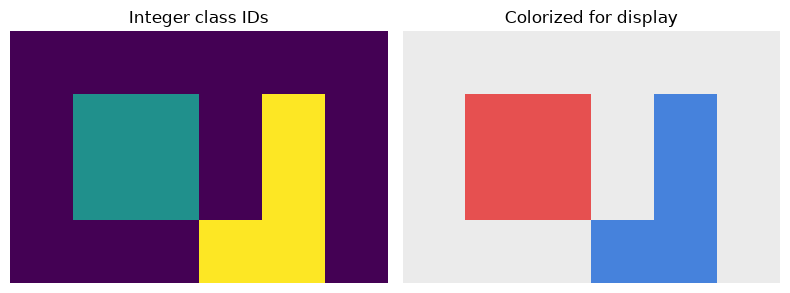

In [3]:
target_mask = np.array([
    [0, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 2, 0],
    [0, 1, 1, 0, 2, 0],
    [0, 0, 0, 2, 2, 0],
], dtype=np.int64)

def colorize_mask(mask, colors):
    """Replace every integer class ID with its RGB color."""
    # use the mask values to index the color lookup table.
    color_mask = colors[mask]
    return color_mask

colored_target = colorize_mask(target_mask, CLASS_COLORS)
assert colored_target.shape == (4, 6, 3)
np.testing.assert_array_equal(colored_target[1, 1], CLASS_COLORS[1])
np.testing.assert_array_equal(colored_target[1, 4], CLASS_COLORS[2])

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(target_mask, cmap="viridis", vmin=0, vmax=2)
axes[0].set_title("Integer class IDs")
axes[1].imshow(colored_target)
axes[1].set_title("Colorized for display")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

## 2. Per-pixel logits

A segmentation head typically returns logits with shape $(N,C,H,W)$ in a channels-first framework. At each pixel there are $C$ numbers—one score per class. Argmax across the class axis chooses the predicted class:

$$\hat y_{n,h,w}=\mathop{\mathrm{argmax}}_c S_{n,c,h,w}.$$

Argmax removes the class dimension, so predicted masks have shape $(N,H,W)$. Softmax is not needed before argmax because it preserves score ordering, although probabilities are useful when confidence is required.

### Exercise 2 — Convert logits into masks

In [45]:
pixel_logits = np.array([
    [
        [[3, 1, 0], [2, 0, 1]],  # class 0
        [[1, 4, 0], [0, 3, 2]],  # class 1
        [[0, 2, 5], [1, 1, 0]],  # class 2
    ]
], dtype=float)

# select the greatest class logit at every (N, H, W) position.
predicted_mask = np.argmax(pixel_logits, axis=1)

assert predicted_mask.shape == (1, 2, 3)
np.testing.assert_array_equal(predicted_mask[0], [[0, 1, 2], [0, 1, 1]])
print(predicted_mask[0])

[[0 1 2]
 [0 1 1]]


In [46]:
(
    pixel_logits[0, :, 0, 0], pixel_logits[0, :, 0, 1], pixel_logits[0, :, 0, 2]
), (
    pixel_logits[0, :, 1, 0], pixel_logits[0, :, 1, 1], pixel_logits[0, :, 1, 2]
)

((array([3., 1., 0.]), array([1., 4., 2.]), array([0., 0., 5.])),
 (array([2., 0., 1.]), array([0., 3., 1.]), array([1., 2., 0.])))

In [47]:
pixel_logits.shape, predicted_mask.shape

((1, 3, 2, 3), (1, 2, 3))

## 3. Per-pixel cross-entropy and ignored pixels

Semantic segmentation applies multiclass cross-entropy at every valid pixel and averages those losses. The math is the same as [ordinary softmax classification](./07_softmax_loss.ipynb); the batch and spatial dimensions are simply treated as a collection of classification examples.

Some target pixels may have an **ignore index**, such as `-1`. This can represent unlabeled, ambiguous, padded, or otherwise excluded regions. Ignored pixels must contribute neither loss nor gradient.

For numerical stability, subtract each pixel's largest logit before calculating log-sum-exp. If $V$ is the set of valid pixels,

$$L=-\frac{1}{|V|}\sum_{i\in V}\log p_{i,y_i}.$$

### Exercise 3 — Implement masked semantic cross-entropy

In [56]:
def semantic_cross_entropy(logits, targets, ignore_index=-1):
    """Return mean cross-entropy over valid pixels."""
    # Move classes last: (N, C, H, W) -> (N, H, W, C).
    logits_last = np.moveaxis(logits, 1, -1)
    print("logits.shape:", logits.shape)
    print("logits_last.shape:", logits_last.shape)
    print("targets.shape:", targets.shape)

    valid = targets != ignore_index
    print("valid.shape:", valid.shape)

    valid_logits = logits_last[valid]
    print("valid_logits.shape:", valid_logits.shape)

    valid_targets = targets[valid]
    print("valid_targets.shape:", valid_targets.shape)

    if valid_targets.size == 0:
        raise ValueError("at least one target pixel must be valid")

    # calculate stable log probabilities and mean correct-class NLL.
    shifted_logits = valid_logits - np.max(valid_logits, axis=-1, keepdims=True)

    log_probabilities = shifted_logits - np.log(np.sum(np.exp(shifted_logits), axis=-1, keepdims=True))
    print("log_probabilities.shape:", log_probabilities.shape)

    losses = -log_probabilities[np.arange(log_probabilities.shape[0]), valid_targets]
    print("losses.shape:", losses.shape)

    loss = np.mean(losses)
    return float(loss)

loss_targets = np.array([[[0, 1, 2], [0, -1, 1]]])
segmentation_loss = semantic_cross_entropy(pixel_logits, loss_targets)
np.testing.assert_allclose(segmentation_loss, 0.233658, rtol=1e-5)
print(f"Mean valid-pixel loss: {segmentation_loss:.6f}")

logits.shape: (1, 3, 2, 3)
logits_last.shape: (1, 2, 3, 3)
targets.shape: (1, 2, 3)
valid.shape: (1, 2, 3)
valid_logits.shape: (5, 3)
valid_targets.shape: (5,)
log_probabilities.shape: (5, 3)
losses.shape: (5,)
Mean valid-pixel loss: 0.233658


## 4. A confusion matrix over pixels

Detection evaluation first matches boxes. Semantic segmentation already has an aligned target and prediction at every pixel, so evaluation can count their class pairs directly.

We define confusion-matrix rows as target classes and columns as predicted classes:

$$M_{i,j}=\text{number of pixels with target }i\text{ and prediction }j.$$

Diagonal entries are correct pixels. Off-diagonal entry $(i,j)$ counts pixels of class $i$ incorrectly predicted as class $j$.

### Exercise 4 — Construct the pixel confusion matrix

In [59]:
def segmentation_confusion_matrix(targets, predictions, number_of_classes, ignore_index=-1):
    """Count target/prediction class pairs over valid pixels."""
    valid = targets != ignore_index
    valid_targets = targets[valid].ravel()
    valid_predictions = predictions[valid].ravel()
    matrix = np.zeros((number_of_classes, number_of_classes), dtype=np.int64)
    # increment matrix[target, prediction] for every valid pixel.
    for target, prediction in zip(valid_targets, valid_predictions):
        matrix[target, prediction] += 1
    return matrix

metric_targets = np.array([
    [0, 0, 1, 1],
    [0, 2, 2, 1],
    [0, 2, -1, 1],
])
metric_predictions = np.array([
    [0, 1, 1, 1],
    [0, 2, 0, 1],
    [0, 2, 1, 1],
])
confusion = segmentation_confusion_matrix(metric_targets, metric_predictions, 3)
np.testing.assert_array_equal(confusion, [[3, 1, 0], [0, 4, 0], [1, 0, 2]])
print(confusion)

[[3 1 0]
 [0 4 0]
 [1 0 2]]


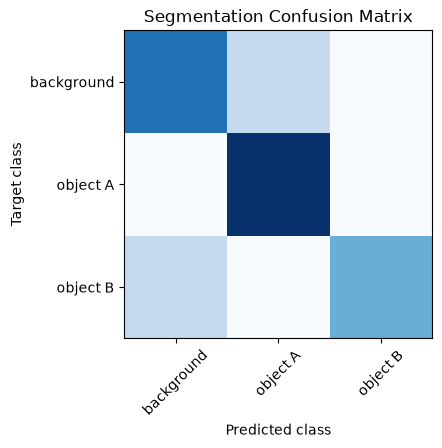

In [60]:
plt.figure(figsize=(4, 4))
plt.imshow(confusion, cmap="Blues", vmin=0)
plt.xticks(np.arange(3), CLASS_NAMES, rotation=45)
plt.yticks(np.arange(3), CLASS_NAMES)
plt.xlabel("Predicted class")
plt.ylabel("Target class")
plt.title("Segmentation Confusion Matrix")
plt.show()

## 5. Pixel accuracy, IoU, and mean IoU

Pixel accuracy is the fraction of valid pixels predicted correctly. It can be misleading when background dominates: a model can classify every pixel as background and still obtain high accuracy.

For class $c$, intersection is its true-positive count. Union contains pixels predicted as $c$ or targeted as $c$, counting their overlap once:

$$\mathrm{IoU}_c=\frac{\mathrm{TP}_c}{\mathrm{TP}_c+\mathrm{FP}_c+\mathrm{FN}_c}.$$

Mean IoU (mIoU) averages class IoUs, usually over classes present according to the benchmark convention. It gives each included class equal weight rather than letting a large background class dominate.

### Exercise 5 — Calculate segmentation metrics from the confusion matrix

In [67]:
def segmentation_metrics(confusion):
    """Return pixel accuracy, per-class IoU, and mean IoU."""
    true_positive = np.diag(confusion)
    target_count = confusion.sum(axis=1)
    predicted_count = confusion.sum(axis=0)
    # calculate pixel accuracy and IoU union per class.
    pixel_accuracy = np.divide(
        true_positive.sum(), target_count.sum(), out=np.full_like(true_positive.sum(), np.nan, dtype=float), where=target_count.sum() > 0
    )
    union = target_count + predicted_count - true_positive
    class_iou = np.divide(
        true_positive, union, out=np.full_like(union, np.nan, dtype=float), where=union > 0
    )
    mean_iou = np.nanmean(class_iou)
    return float(pixel_accuracy), class_iou, float(mean_iou)

pixel_accuracy, class_iou, mean_iou = segmentation_metrics(confusion)
np.testing.assert_allclose(pixel_accuracy, 9 / 11)
np.testing.assert_allclose(class_iou, [3 / 5, 4 / 5, 2 / 3])
np.testing.assert_allclose(mean_iou, 31 / 45)
print(f"Pixel accuracy: {pixel_accuracy:.3f}")
for name, iou in zip(CLASS_NAMES, class_iou):
    print(f"{name:>10}: IoU={iou:.3f}")
print(f"Mean IoU: {mean_iou:.3f}")

Pixel accuracy: 0.818
background: IoU=0.600
  object A: IoU=0.800
  object B: IoU=0.667
Mean IoU: 0.689


In [ ]:
true_positive = np.diag(confusion)
target_count = confusion.sum(axis=1)
predicted_count = confusion.sum(axis=0)
(
    confusion,
    true_positive,
    target_count,
    predicted_count,
    true_positive.sum(),
)

(array([[3, 1, 0],
        [0, 4, 0],
        [1, 0, 2]]),
 array([3, 4, 2]),
 array([4, 4, 3]),
 array([4, 5, 2]),
 np.int64(9))

## 6. Resizing images and label masks

Interpolation is appropriate for continuous image intensities, but integer mask values are class IDs. Averaging class IDs has no semantic meaning: halfway between class 0 and class 2 is not necessarily class 1.

Label masks should therefore normally be resized with **nearest-neighbor** interpolation. Every output pixel copies one existing class ID, so resizing cannot invent fractional or new labels. Model logits are continuous and may be bilinearly upsampled before argmax. The important distinction is between resizing discrete targets and resizing continuous scores or features.

### Exercise 6 — Upsample a label mask without inventing classes

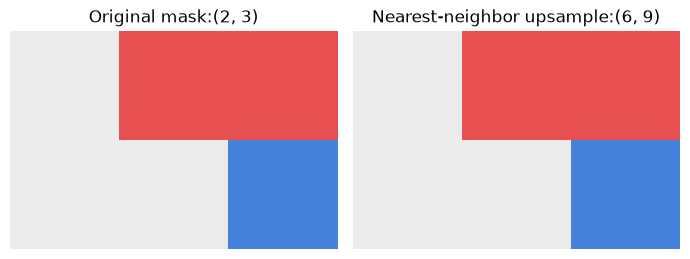

In [73]:
def nearest_upsample_mask(mask, scale_factor):
    """Upsample a 2D mask by repeating rows and columns."""
    # repeat each row and each column scale_factor times.
    upsampled = np.repeat(np.repeat(mask, scale_factor, axis=0), scale_factor, axis=1)
    return upsampled

small_mask = np.array([[0, 1, 1], [0, 0, 2]])
large_mask = nearest_upsample_mask(small_mask, scale_factor=3)
assert large_mask.shape == (6, 9)
np.testing.assert_array_equal(np.unique(large_mask), np.unique(small_mask))
np.testing.assert_array_equal(large_mask[:3, :3], np.zeros((3, 3)))

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(colorize_mask(small_mask, CLASS_COLORS))
axes[0].set_title("Original mask:{0}".format(small_mask.shape))
axes[1].imshow(colorize_mask(large_mask, CLASS_COLORS))
axes[1].set_title("Nearest-neighbor upsample:{0}".format(large_mask.shape))
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

## 7. Producing detailed output from deep features

Classification CNNs repeatedly downsample spatial dimensions. This is useful for recognition and efficiency, but segmentation must eventually return a prediction at every image location. The three ideas below are not mutually exclusive model categories. They solve different parts of the same problem and are often combined in one segmentation network.

### Fully convolutional networks

A Fully Convolutional Network (FCN) replaces the fixed fully connected classification head with convolutional layers. A classifier might reduce an image to one vector of class scores, but an FCN keeps a spatial grid and predicts one class-score vector at every grid location.

For example, an input of shape $(3,32,32)$ might become deep features of shape $(128,4,4)$ and then class logits of shape $(C,4,4)$. Upsampling changes those coarse logits to $(C,32,32)$ before selecting a class at every pixel. The deep $4\times4$ cells know *what* is present, but simple upsampling cannot recreate precise boundaries that were lost during downsampling. FCN describes the basic change from one image prediction to a spatial prediction; it does not by itself specify a sophisticated decoder.

### Encoder–decoder and skip connections

An **encoder** gradually reduces height and width while increasing semantic abstraction. Its deep features have a large receptive field and can recognize an object, but their spatial layout is coarse. A **decoder** gradually restores resolution using interpolation, learned transposed convolutions, or upsampling followed by ordinary convolutions.

Upsampling deep features alone still cannot recover information that the encoder discarded. U-Net-style **skip connections** therefore copy features from an earlier encoder level directly to the decoder level with the same spatial resolution. The decoder combines two kinds of evidence:

- deep, low-resolution features provide semantic context: *this region is probably a bicycle*;
- shallow, high-resolution features preserve local detail: *an edge passes through these pixels*.

The skipped tensor is normally concatenated with, or added to, the decoder tensor; it is not itself the final segmentation mask. Later convolutions learn how to combine both sources.

```text
encoder:  image -> H x W -> H/2 x W/2 -> H/4 x W/4
                    |              |          |
                    +---- skip ----+----------+
                                             |
decoder:                       H/4 x W/4 -> H/2 x W/2 -> H x W -> logits
```

### Dilated convolution and context

An ordinary $3\times3$ convolution samples adjacent positions. A $3\times3$ convolution with dilation 2 leaves a one-position gap between samples, so its nine weights cover an effective $5\times5$ region. In one dimension, the sampled offsets are $[-1,0,1]$ for dilation 1 and $[-2,0,2]$ for dilation 2.

Dilation therefore gives each output access to wider context without pooling, changing the feature-map resolution, or increasing the number of kernel parameters. This is useful when a pixel needs surrounding object context but its precise location must be retained. A limitation is that widely spaced samples can miss fine local patterns, so DeepLab-style systems commonly combine several dilation rates or combine dilation with other features.

### How the three ideas fit together

| Idea | Main operation | Main benefit | What it does not solve alone |
| --- | --- | --- | --- |
| FCN | Replace a single classification output with a spatial score map | Enables dense, variable-size prediction | A coarse score map still has imprecise boundaries |
| Encoder–decoder with skips | Upsample deep features and merge earlier high-resolution features | Combines semantic meaning with spatial detail | Adds computation and requires compatible feature shapes |
| Dilated convolution | Spread kernel samples apart without downsampling | Enlarges context while preserving resolution | A large dilation can sample the input too sparsely |

A model can use all three: be fully convolutional, use dilated convolutions in its encoder, and use an encoder–decoder with skip connections. The visualization below focuses on the distinct job performed by each idea.

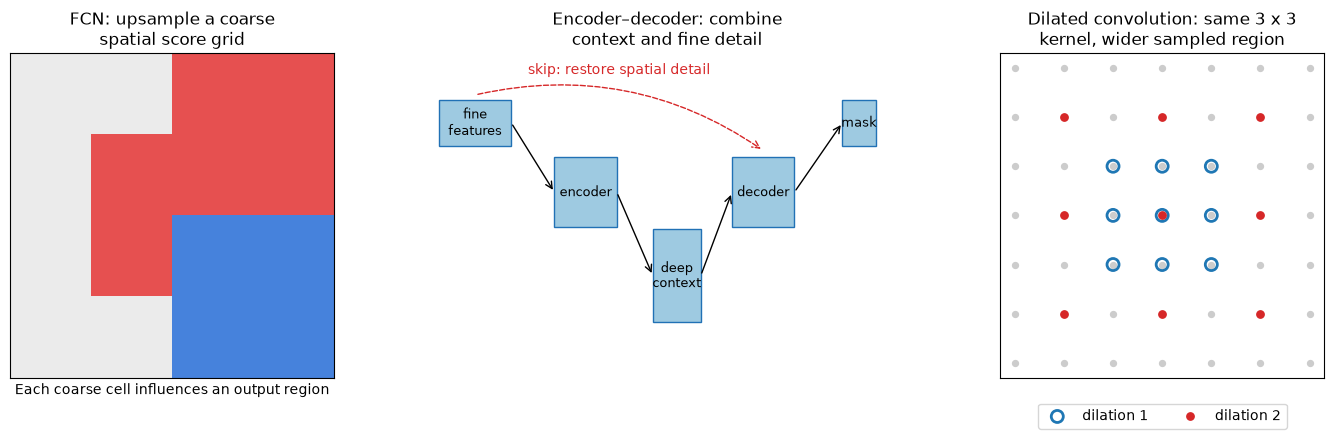

In [74]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import FancyArrowPatch, Rectangle

class_cmap = ListedColormap(CLASS_COLORS / 255.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. FCN: spatial predictions are coarse and then expanded to the input size.
axis = axes[0]
axis.imshow(np.kron(np.array([[0, 0, 1, 1],
                              [0, 1, 1, 1],
                              [0, 1, 2, 2],
                              [0, 0, 2, 2]]), np.ones((2, 2))),
            cmap=class_cmap, vmin=0, vmax=2, interpolation="nearest")
axis.set_title("FCN: upsample a coarse\nspatial score grid")
axis.set_xlabel("Each coarse cell influences an output region")
axis.set_xticks([])
axis.set_yticks([])

# 2. Encoder-decoder: show a U-shaped path and a high-resolution skip.
axis = axes[1]
axis.set_xlim(0, 10)
axis.set_ylim(0, 7)
stages = [(1, 5.5, 1.5, 1.0, "fine\nfeatures"),
          (3.3, 4.0, 1.3, 1.5, "encoder"),
          (5.2, 2.2, 1.0, 2.0, "deep\ncontext"),
          (7.0, 4.0, 1.3, 1.5, "decoder"),
          (9.0, 5.5, 0.7, 1.0, "mask")]
for x, y, width, height, label in stages:
    axis.add_patch(Rectangle((x - width / 2, y - height / 2), width, height,
                             facecolor="#9ecae1", edgecolor="#2171b5"))
    axis.text(x, y, label, ha="center", va="center", fontsize=9)
for first, second in zip(stages[:-1], stages[1:]):
    axis.add_patch(FancyArrowPatch((first[0] + first[2] / 2, first[1]),
                                   (second[0] - second[2] / 2, second[1]),
                                   arrowstyle="->", mutation_scale=12))
axis.add_patch(FancyArrowPatch((1, 6.1), (7, 4.9), connectionstyle="arc3,rad=-0.22",
                               arrowstyle="->", mutation_scale=13,
                               linestyle="--", color="#d62728"))
axis.text(4.0, 6.55, "skip: restore spatial detail", color="#d62728", ha="center")
axis.set_title("Encoder–decoder: combine\ncontext and fine detail")
axis.axis("off")

# 3. Dilation: the same 3 x 3 weights inspect a wider part of the feature map.
axis = axes[2]
grid_y, grid_x = np.mgrid[0:7, 0:7]
axis.scatter(grid_x, grid_y, s=18, color="#cccccc")
ordinary = np.array([(x, y) for y in range(2, 5) for x in range(2, 5)])
dilated = np.array([(x, y) for y in (1, 3, 5) for x in (1, 3, 5)])
axis.scatter(ordinary[:, 0], ordinary[:, 1], s=75, facecolors="none",
             edgecolors="#1f77b4", linewidths=2, label="dilation 1")
axis.scatter(dilated[:, 0], dilated[:, 1], s=28, color="#d62728", label="dilation 2")
axis.set_title("Dilated convolution: same 3 x 3\nkernel, wider sampled region")
axis.set_aspect("equal")
axis.invert_yaxis()
axis.set_xticks([])
axis.set_yticks([])
axis.legend(loc="lower center", bbox_to_anchor=(0.5, -0.18), ncol=2)

plt.tight_layout()
plt.show()

## 8. What semantic segmentation does not distinguish

If an image contains two cats, semantic segmentation labels both sets of pixels as `cat`. It does not say which pixels belong to cat 1 and which belong to cat 2. Instance segmentation adds separate object identities, while panoptic segmentation provides a unified interpretation of countable object instances and amorphous background regions. These will be the focus of a [later notebook](./43_instance_and_panoptic_segmentation.ipynb).

## Reflection

Answer briefly in your own words.

1. How does semantic segmentation differ from image classification and object detection?
2. Why do logits have shape $(N,C,H,W)$ while target masks have shape $(N,H,W)$?
3. Why is softmax unnecessary before choosing the argmax class?
4. What happens to ignored pixels during loss calculation?
5. What do the rows and columns of the segmentation confusion matrix represent?
6. Why can pixel accuracy be misleading when background occupies most of an image?
7. What does the union in class IoU contain?
8. Why should discrete target masks use nearest-neighbor resizing?
9. How do encoder–decoder skip connections help segmentation?
10. Why does semantic segmentation not distinguish two objects of the same class?

### Answers

1. Semantic segmentation predicts a class for every pixel. Image classification predicts one class for the entire image, while object detection predicts a variable set of class-labelled bounding boxes.
2. C is number of possible classes, for prediction we need just one number that identifies class. The logits contain one score for every possible class at every pixel, hence $(N,C,H,W)$. The target contains only the correct class index for each pixel, hence $(N,H,W)$.
3. it is not nessesary to have probabilities for choosing class. Softmax changes scores into probabilities but preserves their ordering, so it does not change argmax
4. they are not considered for loss calculation. Ignored pixels contribute neither to the loss sum nor to the number of pixels used for the mean.
5. target and prediction classes. rows represent target classes, columns represent predicted classes, and each entry counts pixels with that target–prediction combination.
6. accuracy might be high even if all predictions are background. A model predicting background everywhere could obtain high pixel accuracy if background dominates the image.
7. true positive, false positive and false negatives. For a class, the union contains its true positives, false positives, and false negatives:
$
\text{union} = TP + FP + FN.
$
8. Nearest-neighbor resizing copies existing class IDs. Continuous interpolation could average IDs and invent meaningless fractional or unintended class values.
9. by combining deep semantic decoder and spatial encoder features. Skip connections combine high-resolution encoder features containing boundary and location details with deeper decoder features containing semantic context.
10. it distinguish only class of pixel. all same class objects will be classified identically. Semantic segmentation assigns semantic classes but no instance identities, so two objects of the same class receive the same label.